In [1]:
import sympy as sp

**Ejercicio 1.** Calcular los coeficientes de Fourier de las funciones periódicas de período $2\pi$ que siguen. Indicar en qué casos el criterio de Weierstrass permite asegurar la convergencia uniforme de las series que resultan:

1. $f(x)=x^2$ en $(-\pi,\pi)$;

8. 
\[
f(x)=
\begin{cases}
0, & \text{si } x\in(-\pi,0),\\
x, & \text{si } x\in(0,\pi);
\end{cases}
\]

9. 
\[
f(x)=
\begin{cases}
-e^{-x}, & \text{si } x\in(-\pi,0),\\
e^x, & \text{si } x\in(0,\pi).
\end{cases}
\]

In [2]:
x = sp.symbols('x')

f = x**2

serie = sp.fourier_series(f, (x, -sp.pi, sp.pi))

serie.truncate(1)

pi**2/3

In [3]:
x, n = sp.symbols('x n', integer=True, positive=True)

f = x**2

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, -sp.pi, sp.pi))

bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, -sp.pi, sp.pi))

print(f'Coeficientes: a0: {a0}, a_n: {an}, b_n: {bn}')

serie = sp.fourier_series(f, (x, -sp.pi, sp.pi))

serie.truncate(1)

Coeficientes: a0: 2*pi**2/3, a_n: 4*(-1)**n/n**2, b_n: 0


pi**2/3

a0 = 2*pi**2/3
an = 4*(-1)**n/n**2
bn = 0


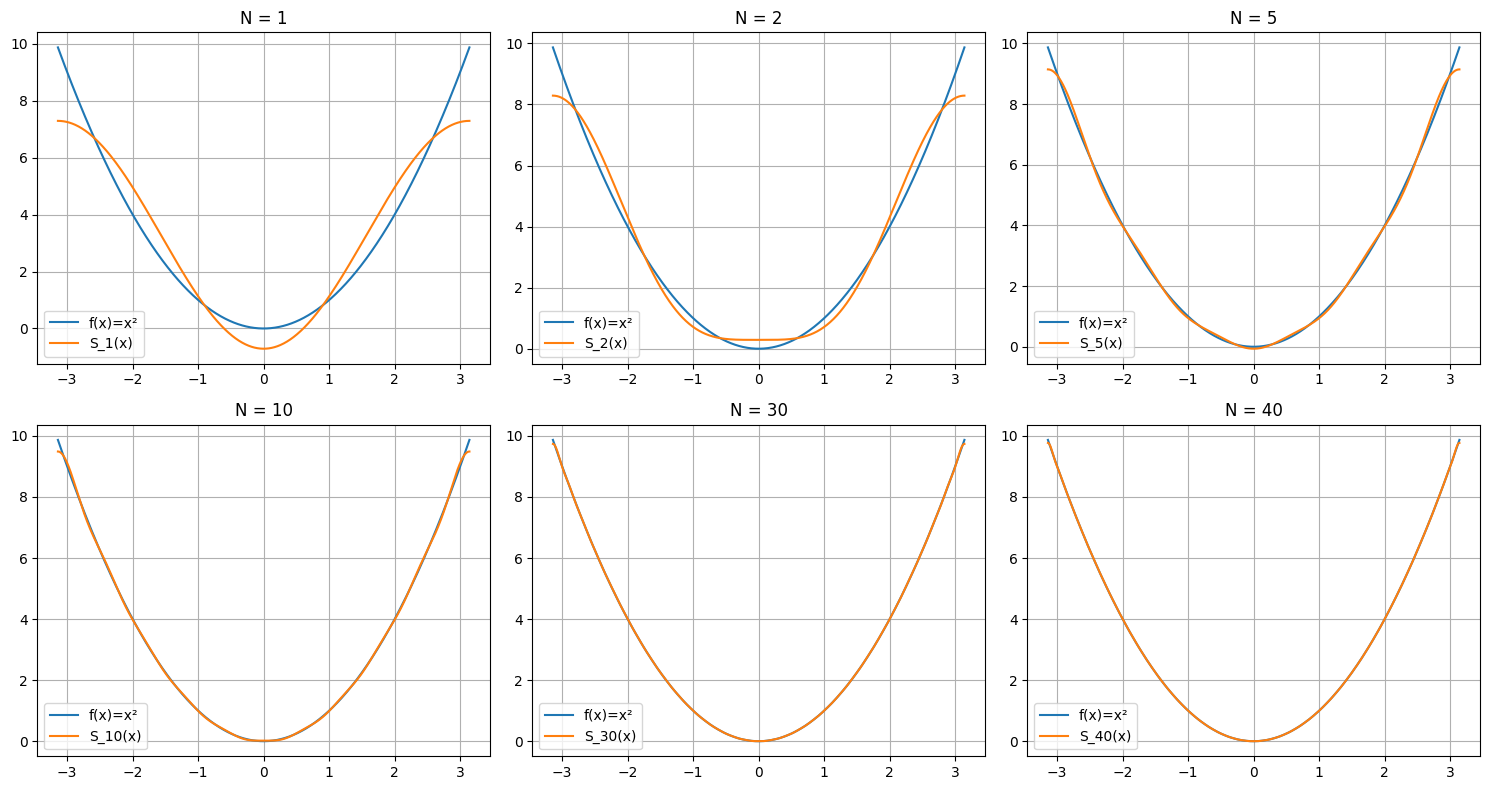

In [13]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# Variables simbólicas
# -------------------------------------------------

x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)

# -------------------------------------------------
# Función
# -------------------------------------------------

f = x**2

# -------------------------------------------------
# Coeficientes de Fourier
# -------------------------------------------------

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(
    f * sp.cos(n*x),
    (x, -sp.pi, sp.pi)
)

bn = (1/sp.pi) * sp.integrate(
    f * sp.sin(n*x),
    (x, -sp.pi, sp.pi)
)

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

# -------------------------------------------------
# Construcción manual de la suma parcial
# -------------------------------------------------

def fourier_partial_sum(N):
    
    suma = a0 / 2
    
    for k in range(1, N + 1):
        
        ak = an.subs(n, k)
        bk = bn.subs(n, k)
        
        suma += (
            ak * sp.cos(k*x)
            + bk * sp.sin(k*x)
        )
    
    return sp.simplify(suma)

# -------------------------------------------------
# Valores de N para comparar
# -------------------------------------------------

Ns = [1, 2, 5, 10, 30, 40]

# -------------------------------------------------
# Mallado numérico
# -------------------------------------------------

x_vals = np.linspace(-np.pi, np.pi, 1000)

# Función original
f_lamb = sp.lambdify(x, f, 'numpy')

# -------------------------------------------------
# Subplots
# -------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes = axes.flatten()

for ax, N in zip(axes, Ns):
    
    # suma parcial simbólica
    SN = fourier_partial_sum(N)
    
    # convertir a función numérica
    SN_lamb = sp.lambdify(x, SN, 'numpy')
    
    # evaluar
    y_fourier = SN_lamb(x_vals)
    y_real = f_lamb(x_vals)
    
    # graficar
    ax.plot(x_vals, y_real, label='f(x)=x²')
    ax.plot(x_vals, y_fourier, label=f'S_{N}(x)')
    
    ax.set_title(f'N = {N}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

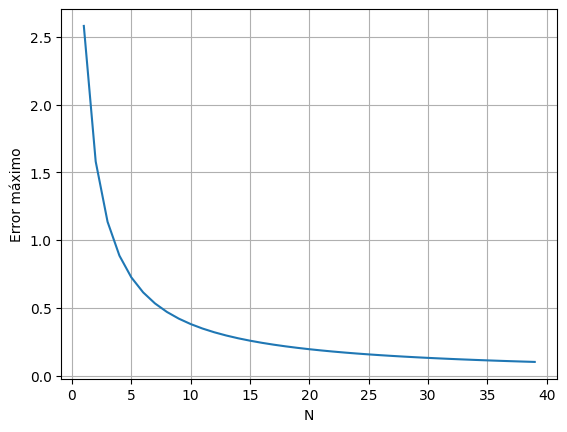

In [14]:
errores = []

for N in range(1, 40):

    SN = fourier_partial_sum(N)

    SN_lamb = sp.lambdify(x, SN, 'numpy')

    error = np.max(
        np.abs(
            SN_lamb(x_vals) - f_lamb(x_vals)
        )
    )

    errores.append(error)

plt.plot(range(1, 40), errores)
plt.xlabel("N")
plt.ylabel("Error máximo")
plt.grid(True)
plt.show()

a0 = 0
an = 0
bn = -2*(-1)**n/n


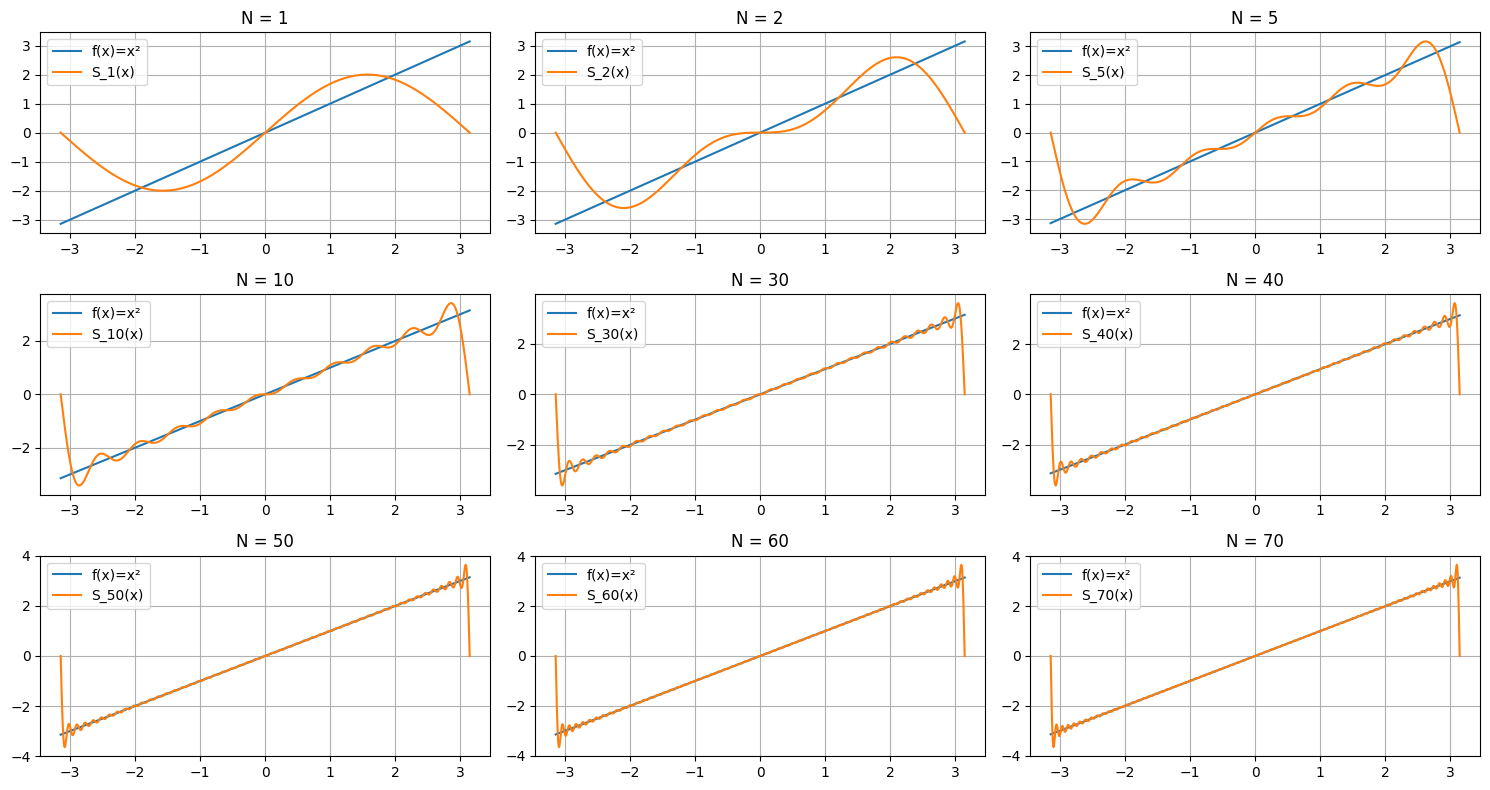

In [17]:
# -------------------------------------------------
# Variables simbólicas
# -------------------------------------------------

x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)

# -------------------------------------------------
# Función
# -------------------------------------------------

f = x

# -------------------------------------------------
# Coeficientes de Fourier
# -------------------------------------------------

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(
    f * sp.cos(n*x),
    (x, -sp.pi, sp.pi)
)

bn = (1/sp.pi) * sp.integrate(
    f * sp.sin(n*x),
    (x, -sp.pi, sp.pi)
)

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

# -------------------------------------------------
# Construcción manual de la suma parcial
# -------------------------------------------------

def fourier_partial_sum(N):
    
    suma = a0 / 2
    
    for k in range(1, N + 1):
        
        ak = an.subs(n, k)
        bk = bn.subs(n, k)
        
        suma += (
            ak * sp.cos(k*x)
            + bk * sp.sin(k*x)
        )
    
    return sp.simplify(suma)

# -------------------------------------------------
# Valores de N para comparar
# -------------------------------------------------

Ns = [1, 2, 5, 10, 30, 40, 50, 60, 70]

# -------------------------------------------------
# Mallado numérico
# -------------------------------------------------

x_vals = np.linspace(-np.pi, np.pi, 1000)

# Función original
f_lamb = sp.lambdify(x, f, 'numpy')

# -------------------------------------------------
# Subplots
# -------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 8))

axes = axes.flatten()

for ax, N in zip(axes, Ns):
    
    # suma parcial simbólica
    SN = fourier_partial_sum(N)
    
    # convertir a función numérica
    SN_lamb = sp.lambdify(x, SN, 'numpy')
    
    # evaluar
    y_fourier = SN_lamb(x_vals)
    y_real = f_lamb(x_vals)
    
    # graficar
    ax.plot(x_vals, y_real, label='f(x)=x²')
    ax.plot(x_vals, y_fourier, label=f'S_{N}(x)')
    
    ax.set_title(f'N = {N}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

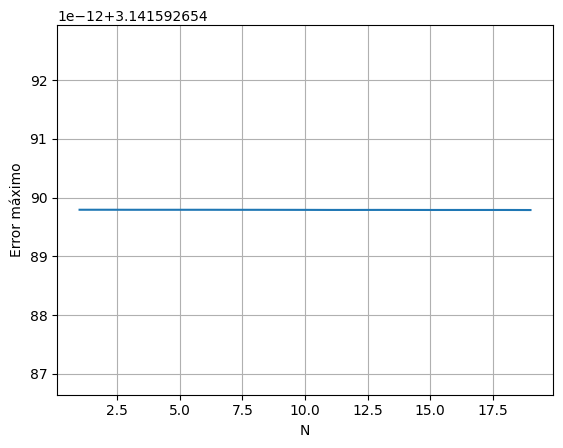

In [21]:
errores = []

for N in range(1, 20):

    SN = fourier_partial_sum(N)

    SN_lamb = sp.lambdify(x, SN, 'numpy')

    error = np.max(
        np.abs(
            SN_lamb(x_vals) - f_lamb(x_vals)
        )
    )

    errores.append(error)

plt.plot(range(1, 20), errores)
plt.xlabel("N")
plt.ylabel("Error máximo")
plt.grid(True)
plt.show()

2. $f(x)=x^2$ en $(0,2\pi)$;

In [6]:
x, n = sp.symbols('x n', integer=True, positive=True)

f = x**2

a0 = (1/sp.pi) * sp.integrate(f, (x, 0, 2 * sp.pi))

an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, 0, 2 * sp.pi))

bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, 0, 2 * sp.pi))

print(f'Coeficientes: a0: {a0}, a_n: {an}, b_n: {bn}')

serie = sp.fourier_series(f, (x, 0, 2 * sp.pi))

serie.truncate(1)

Coeficientes: a0: 8*pi**2/3, a_n: 4/n**2, b_n: -4*pi/n


4*pi**2/3

a0 = 2*pi**2/3
an = 4*(-1)**n/n**2
bn = 0


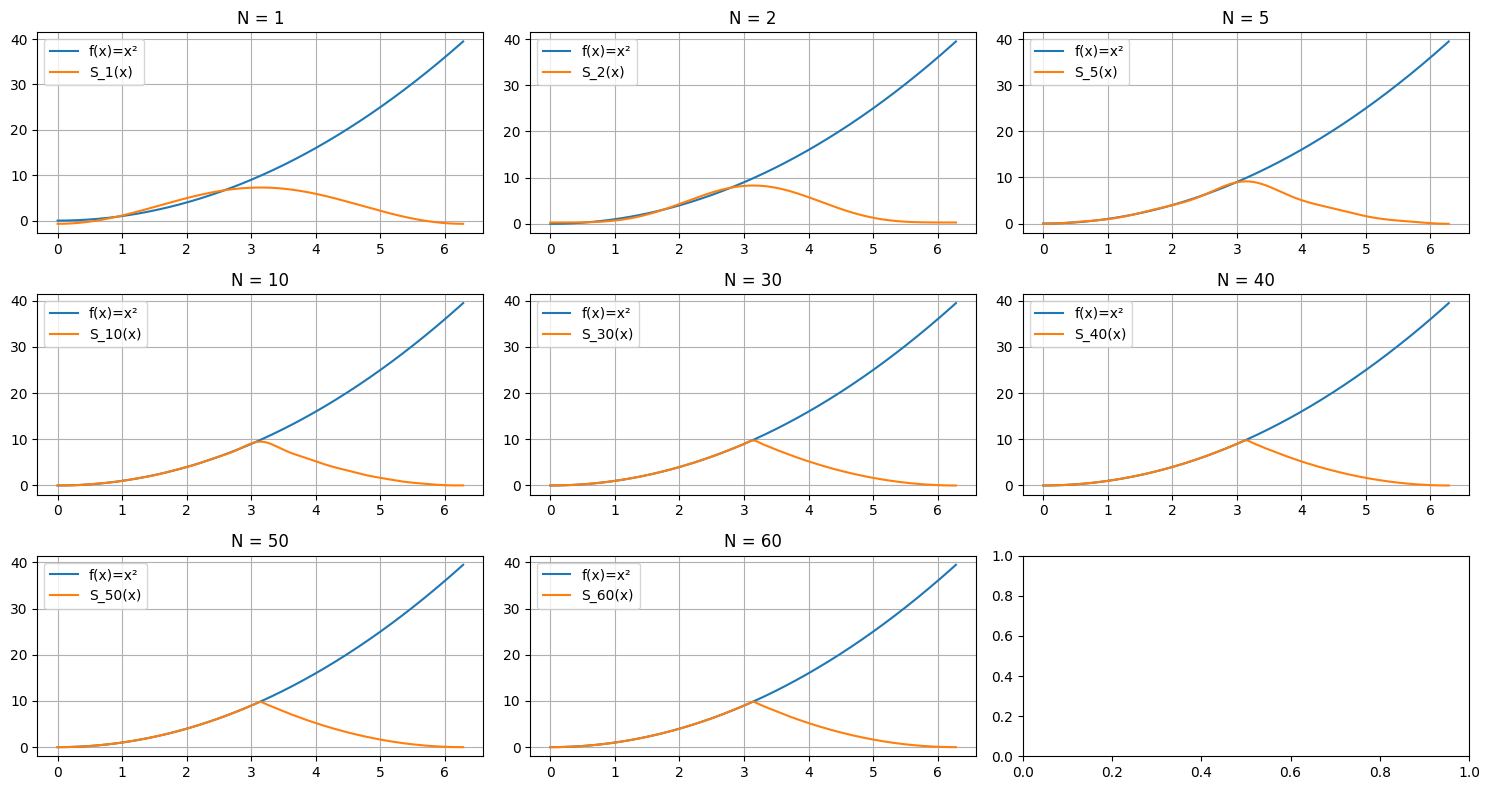

In [24]:
# -------------------------------------------------
# Variables simbólicas
# -------------------------------------------------

x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)

# -------------------------------------------------
# Función
# -------------------------------------------------

f = x**2

# -------------------------------------------------
# Coeficientes de Fourier
# -------------------------------------------------

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(
    f * sp.cos(n*x),
    (x, -sp.pi, sp.pi)
)

bn = (1/sp.pi) * sp.integrate(
    f * sp.sin(n*x),
    (x, -sp.pi, sp.pi)
)

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

# -------------------------------------------------
# Construcción manual de la suma parcial
# -------------------------------------------------

def fourier_partial_sum(N):
    
    suma = a0 / 2
    
    for k in range(1, N + 1):
        
        ak = an.subs(n, k)
        bk = bn.subs(n, k)
        
        suma += (
            ak * sp.cos(k*x)
            + bk * sp.sin(k*x)
        )
    
    return sp.simplify(suma)

# -------------------------------------------------
# Valores de N para comparar
# -------------------------------------------------

Ns = [1, 2, 5, 10, 30, 40, 50, 60]

# -------------------------------------------------
# Mallado numérico
# -------------------------------------------------

x_vals = np.linspace(0, 2*np.pi, 1000)

# Función original
f_lamb = sp.lambdify(x, f, 'numpy')

# -------------------------------------------------
# Subplots
# -------------------------------------------------

fig, axes = plt.subplots(3, 3, figsize=(15, 8))

axes = axes.flatten()

for ax, N in zip(axes, Ns):
    
    # suma parcial simbólica
    SN = fourier_partial_sum(N)
    
    # convertir a función numérica
    SN_lamb = sp.lambdify(x, SN, 'numpy')
    
    # evaluar
    y_fourier = SN_lamb(x_vals)
    y_real = f_lamb(x_vals)
    
    # graficar
    ax.plot(x_vals, y_real, label='f(x)=x²')
    ax.plot(x_vals, y_fourier, label=f'S_{N}(x)')
    
    ax.set_title(f'N = {N}')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

3. $f(x)=|\sin x|$ en $(-\pi,\pi)$;

In [7]:
x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)

f = sp.Abs(sp.sin(x))

a0 = (1/sp.pi) * (
    sp.integrate(-sp.sin(x), (x, -sp.pi, 0)) +
    sp.integrate(sp.sin(x), (x, 0, sp.pi))
)

an = (1/sp.pi) * (
    sp.integrate(-sp.sin(x) * sp.cos(n*x), (x, -sp.pi, 0)) +
    sp.integrate(sp.sin(x) * sp.cos(n*x), (x, 0, sp.pi))
)

bn = (1/sp.pi) * (
    sp.integrate(-sp.sin(x) * sp.sin(n*x), (x, -sp.pi, 0)) +
    sp.integrate(sp.sin(x) * sp.sin(n*x), (x, 0, sp.pi))
)

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

serie = sp.fourier_series(f, (x, -sp.pi, sp.pi))

serie.truncate(5)

a0 = 4/pi
an = Piecewise((2*((-1)**(n + 1) - 1)/(pi*(n**2 - 1)), n > 1), (0, True))
bn = 0


-4*cos(2*x)/(3*pi) - 4*cos(4*x)/(15*pi) - 4*cos(6*x)/(35*pi) - 4*cos(8*x)/(63*pi) + 2/pi

In [8]:
x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)

f = sp.sin(x)

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, -sp.pi, sp.pi))

bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, -sp.pi, sp.pi))

print(f'Coeficientes: a0: {a0}, a_n: {an}, b_n: {bn}')

serie = sp.fourier_series(f, (x, -sp.pi, sp.pi))

serie.truncate(8)

Coeficientes: a0: 0, a_n: 0, b_n: Piecewise((0, Ne(n, 1)), (pi, True))/pi


sin(x)

4. $f(x)=e^{ax}$ en $(-\pi,\pi)$ con $a\neq 0$;

In [9]:
x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)
a = sp.symbols('a', real=True, nonzero=True)

f = sp.exp(a*x)

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, -sp.pi, sp.pi))

bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, -sp.pi, sp.pi))

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

serie = sp.fourier_series(f, (x, -sp.pi, sp.pi))
print(f'Serie con 3 terminos: {serie.truncate(2)}')
    

a0 = 2*sinh(pi*a)/(pi*a)
an = 2*(-1)**n*a*sinh(pi*a)/(pi*(a**2 + n**2))
bn = -2*(-1)**n*n*sinh(pi*a)/(pi*(a**2 + n**2))
Serie con 3 terminos: (exp(pi*a)/a - exp(-pi*a)/a)/(2*pi) + (exp(pi*a)/(a**2 + 1) - exp(-pi*a)/(a**2 + 1))*sin(x)/pi + (-a*exp(pi*a)/(a**2 + 1) + a*exp(-pi*a)/(a**2 + 1))*cos(x)/pi


In [10]:
a_values = [-1, 1, 2]

for a_val in a_values:
    f = sp.exp(a_val * x)
    
    a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))
    an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, -sp.pi, sp.pi))
    bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, -sp.pi, sp.pi))

    print(f"\na = {a_val}")
    print("a0 =", sp.simplify(a0))
    print("an =", sp.simplify(an))
    print("bn =", sp.simplify(bn))
    
    serie = sp.fourier_series(f, (x, -sp.pi, sp.pi))
    print(f'Serie con 3 terminos: {serie.truncate(2)}')


a = -1
a0 = 2*sinh(pi)/pi
an = 2*(-1)**n*sinh(pi)/(pi*(n**2 + 1))
bn = 2*(-1)**n*n*sinh(pi)/(pi*(n**2 + 1))
Serie con 3 terminos: (-exp(pi)/2 + exp(-pi)/2)*sin(x)/pi + (-exp(pi)/2 + exp(-pi)/2)*cos(x)/pi + (-exp(-pi) + exp(pi))/(2*pi)

a = 1
a0 = 2*sinh(pi)/pi
an = 2*(-1)**n*sinh(pi)/(pi*(n**2 + 1))
bn = -2*(-1)**n*n*sinh(pi)/(pi*(n**2 + 1))
Serie con 3 terminos: (-exp(-pi)/2 + exp(pi)/2)*sin(x)/pi + (-exp(pi)/2 + exp(-pi)/2)*cos(x)/pi + (-exp(-pi) + exp(pi))/(2*pi)

a = 2
a0 = sinh(2*pi)/pi
an = 4*(-1)**n*sinh(2*pi)/(pi*(n**2 + 4))
bn = -2*(-1)**n*n*sinh(2*pi)/(pi*(n**2 + 4))
Serie con 3 terminos: (-exp(-2*pi)/5 + exp(2*pi)/5)*sin(x)/pi + (-2*exp(2*pi)/5 + 2*exp(-2*pi)/5)*cos(x)/pi + (-exp(-2*pi)/2 + exp(2*pi)/2)/(2*pi)


5. $f(x)=\cos(ax)$ en $(-\pi,\pi)$ con $a$ no entero;

In [11]:
x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)
a = sp.symbols('a', real=True)

f = sp.cos(a*x)

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, -sp.pi, sp.pi))

bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, -sp.pi, sp.pi))

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

a0 = Piecewise((2*sin(pi*a)/(pi*a), (a > 0) | (a < 0)), (2, True))
an = Piecewise((1, Eq(a, n) | Eq(a, -n)), (2*(-1)**n*a*sin(pi*a)/(pi*(a**2 - n**2)), True))
bn = 0


6. $f(x)=\sin(ax)$ en $(-\pi,\pi)$ con $a$ no entero;

In [12]:
x = sp.symbols('x', real=True)
n = sp.symbols('n', integer=True, positive=True)
a = sp.symbols('a', real=True)

f = sp.sin(a*x)

a0 = (1/sp.pi) * sp.integrate(f, (x, -sp.pi, sp.pi))

an = (1/sp.pi) * sp.integrate(f * sp.cos(n*x), (x, -sp.pi, sp.pi))

bn = (1/sp.pi) * sp.integrate(f * sp.sin(n*x), (x, -sp.pi, sp.pi))

print("a0 =", sp.simplify(a0))
print("an =", sp.simplify(an))
print("bn =", sp.simplify(bn))

a0 = 0
an = 0
bn = Piecewise((-1, Eq(a, -n)), (1, Eq(a, n)), (2*(-1)**n*n*sin(pi*a)/(pi*(a**2 - n**2)), True))


7. $f(x)=(\pi-x)\sin x$ en $(-\pi,\pi)$;

ValueError: x and y must have same first dimension, but have shapes (2000,) and (1,)

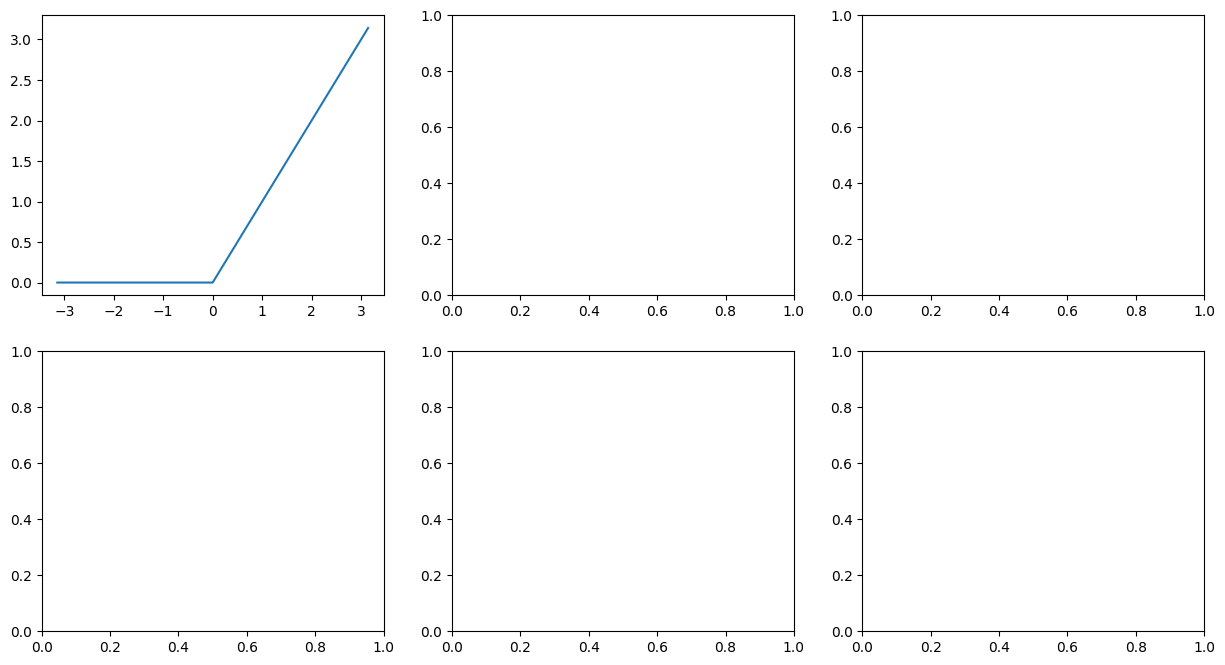

In [26]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# variable
# ------------------------------------------

x = sp.symbols('x', real=True)

# ------------------------------------------
# DEFINIR FUNCION
# ------------------------------------------

f = x**2

# ejemplos:

# f = sp.Abs(sp.sin(x))

# a = 0.7
# f = sp.exp(a*x)

# a = 0.7
# f = sp.cos(a*x)

# a = 0.7
# f = sp.sin(a*x)

# f = (sp.pi - x)*sp.sin(x)

# f = sp.Piecewise(
#     (0, x < 0),
#     (x, x >= 0)
# )

# ------------------------------------------
# Serie de Fourier
# ------------------------------------------

serie = sp.fourier_series(
    f,
    (x, -sp.pi, sp.pi)
)

# ------------------------------------------
# Mallado
# ------------------------------------------

x_vals = np.linspace(
    -np.pi,
    np.pi,
    2000
)

f = sp.Piecewise(
    (0, x < 0),
    (x, x >= 0)
)

# función original
f_lamb = sp.lambdify(
    x,
    f,
    'numpy'
)

# ------------------------------------------
# valores de N
# ------------------------------------------

Ns = [1, 3, 5, 10, 30, 100]

# ------------------------------------------
# subplots
# ------------------------------------------

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

axes = axes.flatten()

for ax, N in zip(axes, Ns):

    SN = serie.truncate(N)

    SN_lamb = sp.lambdify(
        x,
        SN,
        'numpy'
    )

    ax.plot(
        x_vals,
        f_lamb(x_vals),
        label='f(x)'
    )

    ax.plot(
        x_vals,
        SN_lamb(x_vals),
        label=f'N={N}'
    )

    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()